# End-to-End Supervised Learning Workflow: HDB Resale Price Prediction

**Goal**: Build a supervised regression workflow to predict `resale_price` from the training dataset.

**Scenario**

The dataset contains flat, location, distance, school, and transport-related features. The target variable is `resale_price`, so this is a regression problem.

**Workflow**

1. Load and inspect the data.
2. Remove rows with missing values.
3. Split features (`X`) and target (`Y`).
4. Identify categorical, binary, continuous numeric, and remaining numeric columns.
5. Build a preprocessing pipeline that imputes missing values with `0`, then uses `StandardScaler`, `MinMaxScaler`, and one-hot encoding.
6. Evaluate a baseline Linear Regression model with 10-fold cross-validation.
7. Run a train-test split and compare Linear Regression with regularized regression models.
8. Tune Elastic Net hyperparameters with random search.


## 1. Imports and Data Loading

First, import the libraries used throughout the workflow and load the training dataset. The `id` column is used as the dataframe index.


In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 120)
sns.set_theme(style='whitegrid')


In [34]:
# Load the training dataset.
df = pd.read_csv('data/train.csv', dtype={'postal': str})
df.set_index('id', inplace=True)

df.shape


(150634, 76)

In [35]:
# Inspect data types, non-null counts, and example rows.
df.info()
df.head()


<class 'pandas.DataFrame'>
Index: 150634 entries, 88471 to 185947
Data columns (total 76 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Tranc_YearMonth            150634 non-null  str    
 1   town                       150634 non-null  str    
 2   flat_type                  150634 non-null  str    
 3   block                      150634 non-null  str    
 4   street_name                150634 non-null  str    
 5   storey_range               150634 non-null  str    
 6   floor_area_sqm             150634 non-null  float64
 7   flat_model                 150634 non-null  str    
 8   lease_commence_date        150634 non-null  int64  
 9   resale_price               150634 non-null  float64
 10  Tranc_Year                 150634 non-null  int64  
 11  Tranc_Month                150634 non-null  int64  
 12  mid_storey                 150634 non-null  int64  
 13  lower                      150634 non-nul

,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,full_flat_type,address,floor_area_sqft,hdb_age,max_floor_lvl,year_completed,residential,commercial,market_hawker,multistorey_carpark,precinct_pavilion,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,postal,Latitude,Longitude,planning_area,Mall_Nearest_Distance,Mall_Within_500m,Mall_Within_1km,Mall_Within_2km,Hawker_Nearest_Distance,Hawker_Within_500m,Hawker_Within_1km,Hawker_Within_2km,hawker_food_stalls,hawker_market_stalls,mrt_nearest_distance,mrt_name,bus_interchange,mrt_interchange,mrt_latitude,mrt_longitude,bus_stop_nearest_distance,bus_stop_name,bus_stop_latitude,bus_stop_longitude,pri_sch_nearest_distance,pri_sch_name,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
88471,2016-05,KALLANG/WHAMPOA,4 ROOM,3B,UPP BOON KENG RD,10 TO 12,90.0,Model A,2006,680000.0,2016,5,11,10,12,11,4 ROOM Model A,"3B, UPP BOON KENG RD",968.760,15,25,2005,Y,N,N,N,N,142,0,0,0,96,46,0,0,0,0,0,0,0,382003,1.314299,103.872828,Kallang,1094.090418,NaN,NaN,7.0,154.753357,1.0,3.0,13.0,84,60,330.083069,Kallang,0,0,1.311540,103.871731,29.427395,Blk 3B,1.314433,103.872600,1138.633422,Geylang Methodist School,78,1,1.317659,103.882504,1138.633422,Geylang Methodist School,224,0,1.317659,103.882504
122598,2012-07,BISHAN,5 ROOM,153,BISHAN ST 13,07 TO 09,130.0,Improved,1987,665000.0,2012,7,8,7,9,8,5 ROOM Improved,"153, BISHAN ST 13",1399.320,34,9,1987,Y,N,N,N,N,112,0,0,0,56,56,0,0,0,0,0,0,0,570153,1.346086,103.855078,Bishan,866.941448,NaN,1.0,3.0,640.151925,NaN,1.0,7.0,80,77,903.659703,Bishan,1,1,1.350580,103.848305,58.207761,BLK 151A MKT,1.345659,103.855381,415.607357,Kuo Chuan Presbyterian Primary School,45,1,1.349783,103.854529,447.894399,Kuo Chuan Presbyterian Secondary School,232,0,1.350110,103.854892
170897,2013-07,BUKIT BATOK,EXECUTIVE,289B,BT BATOK ST 25,13 TO 15,144.0,Apartment,1997,838000.0,2013,7,14,13,15,14,EXECUTIVE Apartment,"289B, BT BATOK ST 25",1550.016,24,16,1996,Y,N,N,N,N,90,0,0,0,0,30,60,0,0,0,0,0,0,651289,1.343867,103.760535,Bukit Batok,1459.579948,NaN,NaN,4.0,1762.082341,NaN,NaN,1.0,84,95,1334.251197,Bukit Batok,1,0,1.349561,103.749970,214.747860,Blk 289E,1.344064,103.758613,498.849039,Keming Primary School,39,0,1.345245,103.756265,180.074558,Yusof Ishak Secondary School,188,0,1.342334,103.760013
86070,2012-04,BISHAN,4 ROOM,232,BISHAN ST 22,01 TO 05,103.0,Model A,1992,550000.0,2012,4,3,1,5,3,4 ROOM Model A,"232, BISHAN ST 22",1108.692,29,11,1990,Y,Y,N,N,N,75,0,0,0,68,7,0,0,0,0,0,0,0,570232,1.358245,103.845504,Bishan,950.175199,NaN,1.0,4.0,726.215262,NaN,1.0,9.0,32,86,907.453484,Bishan,1,1,1.350580,103.848305,43.396521,Opp Bishan Nth Shop Mall,1.358045,103.845169,389.515528,Catholic High School,20,1,1.354789,103.844934,389.515528,Catholic High School,253,1,1.354789,103.844934
153632,2017-12,YISHUN,4 ROOM,876,YISHUN ST 81,01 TO 03,83.0,Simplified,1987,298000.0,2017,12,2,1,3,2,4 ROOM Simplified,"876, YISHUN ST 81",893.412,34,4,1987,Y,N,N,N,N,48,0,0,0,30,18,0,0,0,0,0,0,0,760876,1.414745,103.835532,Yishun,729.771895,NaN,1.0,2.0,1540.151439,NaN,NaN,1.0,45,0,412.343032,Khatib,0,0,1.417131,103.832692,129.422752,Blk 873,1.415424,103.836477,401.200584,Naval Base Primary School,74,0,1.416280,103.838798,312.025435,Orchid Park Secondary School,208,0,1.414888,103.838335


In [36]:
# Check missing values before deciding how to handle them.
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]


Hawker_Within_500m       97390
Mall_Within_500m         92789
Hawker_Within_1km        60868
Hawker_Within_2km        29202
Mall_Within_1km          25426
Mall_Within_2km           1940
Mall_Nearest_Distance      829
dtype: int64

In [37]:
# for each column, do value counts:
for col in df.columns:
    print(f"Value counts for column '{col}':")
    print(df[col].value_counts(dropna=False))
    print("\n")

Value counts for column 'Tranc_YearMonth':
Tranc_YearMonth
2018-07    2088
2021-01    2019
2020-06    2008
2020-12    2007
2020-09    2005
           ... 
2013-12     818
2014-02     782
2013-02     714
2020-04     339
2020-05     284
Name: count, Length: 110, dtype: int64


Value counts for column 'town':
town
JURONG WEST        11451
WOODLANDS          11334
SENGKANG           11069
TAMPINES           10506
YISHUN             10042
BEDOK               9046
PUNGGOL             7793
HOUGANG             7555
ANG MO KIO          6908
CHOA CHU KANG       6343
BUKIT MERAH         5854
BUKIT PANJANG       5686
BUKIT BATOK         5623
TOA PAYOH           4817
PASIR RIS           4763
KALLANG/WHAMPOA     4340
QUEENSTOWN          4121
GEYLANG             3986
SEMBAWANG           3723
CLEMENTI            3633
JURONG EAST         3470
SERANGOON           3123
BISHAN              2871
CENTRAL AREA        1249
MARINE PARADE        959
BUKIT TIMAH          369
Name: count, dtype: int64


Value cou

## 2. Initial Numeric Distribution Check

Plot the raw numeric columns before preprocessing. This helps verify which variables have wide ranges or skewed distributions.


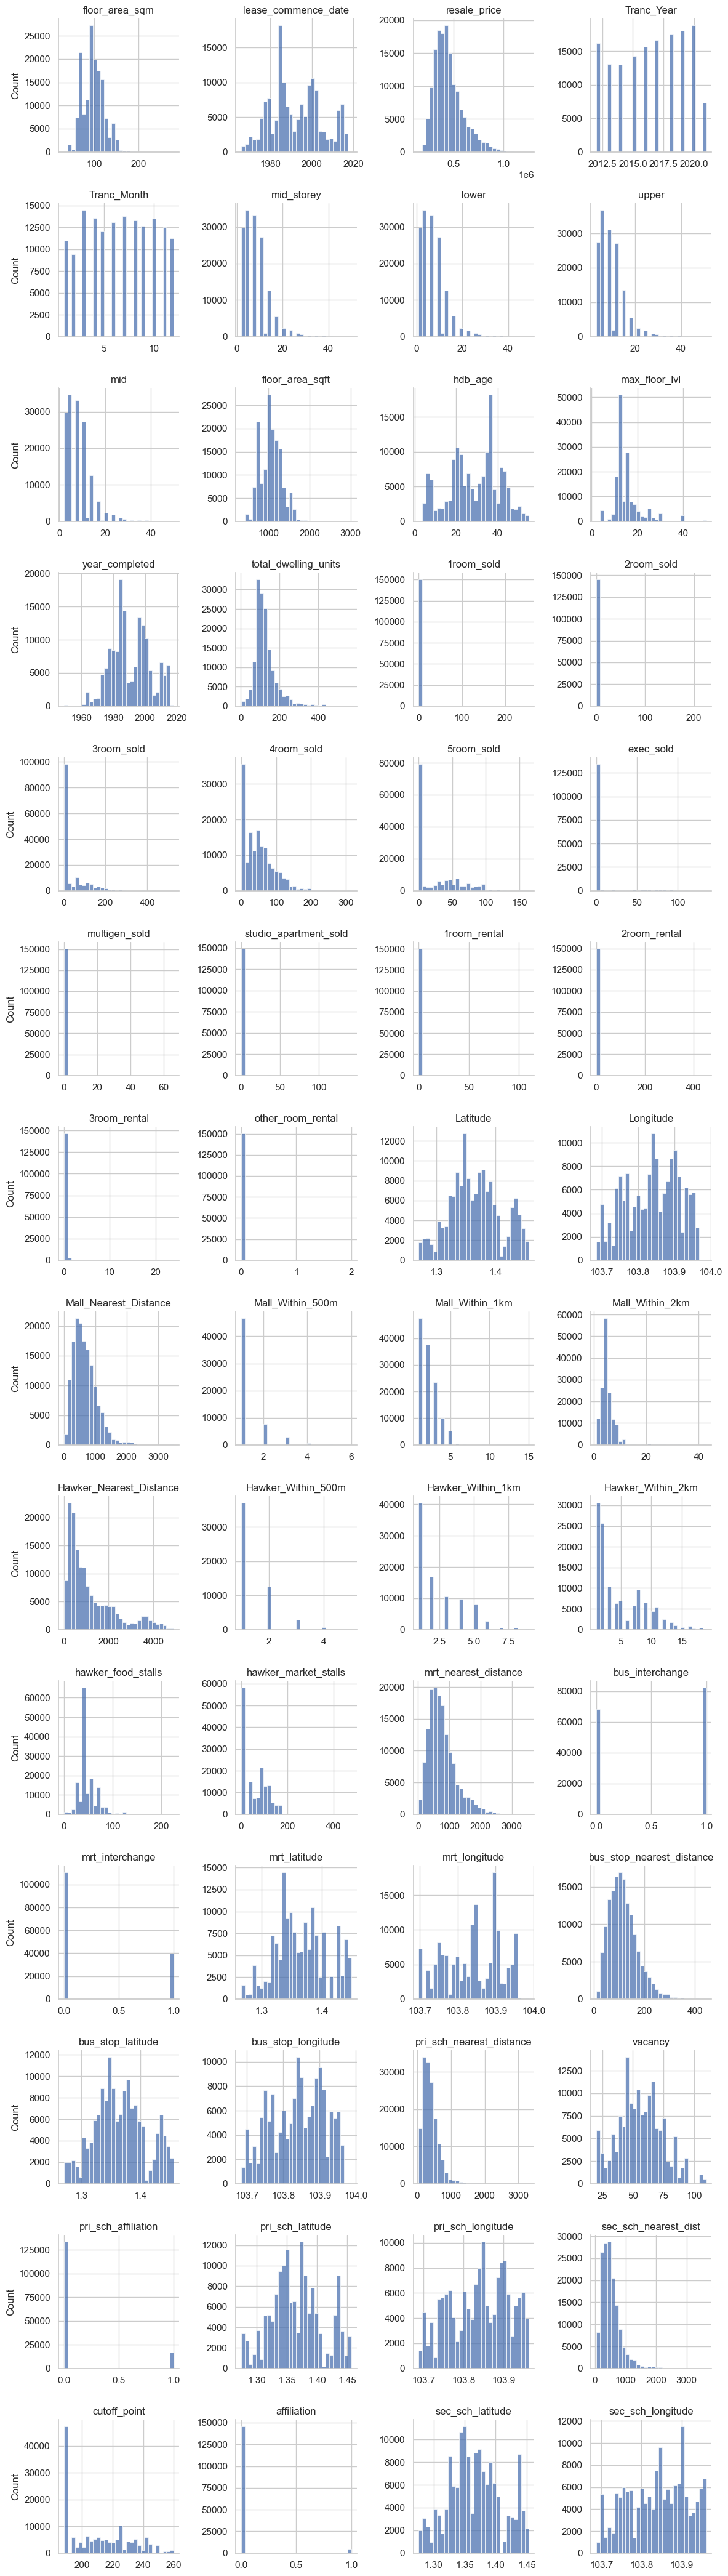

In [38]:
num_cols = df.select_dtypes('number').columns.tolist()
df_melted = df[num_cols].melt(var_name='variable', value_name='value')

g = sns.FacetGrid(df_melted, col='variable', col_wrap=4, height=3, sharey=False, sharex=False)
g.map(sns.histplot, 'value', bins=30, kde=False)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('', 'Count')
plt.tight_layout()
plt.show()


## 3. Feature Engineering Inside the Pipeline

Define feature engineering as a sklearn transformer so the model can receive raw data at both training time and prediction time. The transformer learns the first transaction month during `fit`, then creates `days_from_first_transaction` during every `transform`.

In [39]:
class TransactionDateFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, transaction_col='Tranc_YearMonth', output_col='days_from_first_transaction'):
        self.transaction_col = transaction_col
        self.output_col = output_col

    def fit(self, X, y=None):
        transaction_dates = pd.to_datetime(X[self.transaction_col], format='%Y-%m')
        self.first_transaction_date_ = transaction_dates.min()
        return self

    def transform(self, X):
        X_out = X.copy()
        transaction_dates = pd.to_datetime(X_out[self.transaction_col], format='%Y-%m')
        X_out[self.output_col] = (transaction_dates - self.first_transaction_date_).dt.days
        return X_out


feature_engineer_preview = TransactionDateFeatures().fit(df)
feature_engineer_preview.transform(df)[['Tranc_YearMonth', 'days_from_first_transaction']].head()

,Tranc_YearMonth,days_from_first_transaction
id,,
88471,2016-05,1522
122598,2012-07,122
170897,2013-07,487
86070,2012-04,31
153632,2017-12,2101


## 4. Feature Selection and Target Split

Rows with missing values are removed instead of imputed. Then `resale_price` is separated as the target variable.


In [40]:
df_ml = df.copy()

Y = df_ml['resale_price']
X = df_ml.drop(columns=['resale_price'])

print(f'Original rows: {df.shape[0]}')
print(f'Rows kept for modeling: {df_ml.shape[0]}')
print(f'Features: {X.shape[1]}')
print(f'Target: {Y.name}')

X.head()

Original rows: 150634
Rows kept for modeling: 150634
Features: 75
Target: resale_price


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,Tranc_Year,Tranc_Month,mid_storey,lower,upper,mid,full_flat_type,address,floor_area_sqft,hdb_age,max_floor_lvl,year_completed,residential,commercial,market_hawker,multistorey_carpark,precinct_pavilion,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,postal,Latitude,Longitude,planning_area,Mall_Nearest_Distance,Mall_Within_500m,Mall_Within_1km,Mall_Within_2km,Hawker_Nearest_Distance,Hawker_Within_500m,Hawker_Within_1km,Hawker_Within_2km,hawker_food_stalls,hawker_market_stalls,mrt_nearest_distance,mrt_name,bus_interchange,mrt_interchange,mrt_latitude,mrt_longitude,bus_stop_nearest_distance,bus_stop_name,bus_stop_latitude,bus_stop_longitude,pri_sch_nearest_distance,pri_sch_name,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
88471,2016-05,KALLANG/WHAMPOA,4 ROOM,3B,UPP BOON KENG RD,10 TO 12,90.0,Model A,2006,2016,5,11,10,12,11,4 ROOM Model A,"3B, UPP BOON KENG RD",968.760,15,25,2005,Y,N,N,N,N,142,0,0,0,96,46,0,0,0,0,0,0,0,382003,1.314299,103.872828,Kallang,1094.090418,NaN,NaN,7.0,154.753357,1.0,3.0,13.0,84,60,330.083069,Kallang,0,0,1.311540,103.871731,29.427395,Blk 3B,1.314433,103.872600,1138.633422,Geylang Methodist School,78,1,1.317659,103.882504,1138.633422,Geylang Methodist School,224,0,1.317659,103.882504
122598,2012-07,BISHAN,5 ROOM,153,BISHAN ST 13,07 TO 09,130.0,Improved,1987,2012,7,8,7,9,8,5 ROOM Improved,"153, BISHAN ST 13",1399.320,34,9,1987,Y,N,N,N,N,112,0,0,0,56,56,0,0,0,0,0,0,0,570153,1.346086,103.855078,Bishan,866.941448,NaN,1.0,3.0,640.151925,NaN,1.0,7.0,80,77,903.659703,Bishan,1,1,1.350580,103.848305,58.207761,BLK 151A MKT,1.345659,103.855381,415.607357,Kuo Chuan Presbyterian Primary School,45,1,1.349783,103.854529,447.894399,Kuo Chuan Presbyterian Secondary School,232,0,1.350110,103.854892
170897,2013-07,BUKIT BATOK,EXECUTIVE,289B,BT BATOK ST 25,13 TO 15,144.0,Apartment,1997,2013,7,14,13,15,14,EXECUTIVE Apartment,"289B, BT BATOK ST 25",1550.016,24,16,1996,Y,N,N,N,N,90,0,0,0,0,30,60,0,0,0,0,0,0,651289,1.343867,103.760535,Bukit Batok,1459.579948,NaN,NaN,4.0,1762.082341,NaN,NaN,1.0,84,95,1334.251197,Bukit Batok,1,0,1.349561,103.749970,214.747860,Blk 289E,1.344064,103.758613,498.849039,Keming Primary School,39,0,1.345245,103.756265,180.074558,Yusof Ishak Secondary School,188,0,1.342334,103.760013
86070,2012-04,BISHAN,4 ROOM,232,BISHAN ST 22,01 TO 05,103.0,Model A,1992,2012,4,3,1,5,3,4 ROOM Model A,"232, BISHAN ST 22",1108.692,29,11,1990,Y,Y,N,N,N,75,0,0,0,68,7,0,0,0,0,0,0,0,570232,1.358245,103.845504,Bishan,950.175199,NaN,1.0,4.0,726.215262,NaN,1.0,9.0,32,86,907.453484,Bishan,1,1,1.350580,103.848305,43.396521,Opp Bishan Nth Shop Mall,1.358045,103.845169,389.515528,Catholic High School,20,1,1.354789,103.844934,389.515528,Catholic High School,253,1,1.354789,103.844934
153632,2017-12,YISHUN,4 ROOM,876,YISHUN ST 81,01 TO 03,83.0,Simplified,1987,2017,12,2,1,3,2,4 ROOM Simplified,"876, YISHUN ST 81",893.412,34,4,1987,Y,N,N,N,N,48,0,0,0,30,18,0,0,0,0,0,0,0,760876,1.414745,103.835532,Yishun,729.771895,NaN,1.0,2.0,1540.151439,NaN,NaN,1.0,45,0,412.343032,Khatib,0,0,1.417131,103.832692,129.422752,Blk 873,1.415424,103.836477,401.200584,Naval Base Primary School,74,0,1.416280,103.838798,312.025435,Orchid Park Secondary School,208,0,1.414888,103.838335


## 5. Building the Preprocessing Groups

The preprocessing groups are built in discrete steps:

1. Collect categorical and binary columns.
2. From the remaining numeric columns, identify continuous columns.
3. The leftover numeric columns are treated as non-continuous numeric features.


In [41]:
# Step 1: collect categorical and binary columns.
categorical_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

numeric_candidate_cols = X.select_dtypes(include='number').columns.tolist()
binary_cols = [
    col for col in numeric_candidate_cols
    if X[col].nunique(dropna=True) == 2
]

print(f'Categorical columns ({len(categorical_cols)}):')
print(categorical_cols)
print()
print(f'Binary columns ({len(binary_cols)}):')
print(binary_cols)


Categorical columns (20):
['Tranc_YearMonth', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'flat_model', 'full_flat_type', 'address', 'residential', 'commercial', 'market_hawker', 'multistorey_carpark', 'precinct_pavilion', 'postal', 'planning_area', 'mrt_name', 'bus_stop_name', 'pri_sch_name', 'sec_sch_name']

Binary columns (5):
['1room_sold', 'bus_interchange', 'mrt_interchange', 'pri_sch_affiliation', 'affiliation']


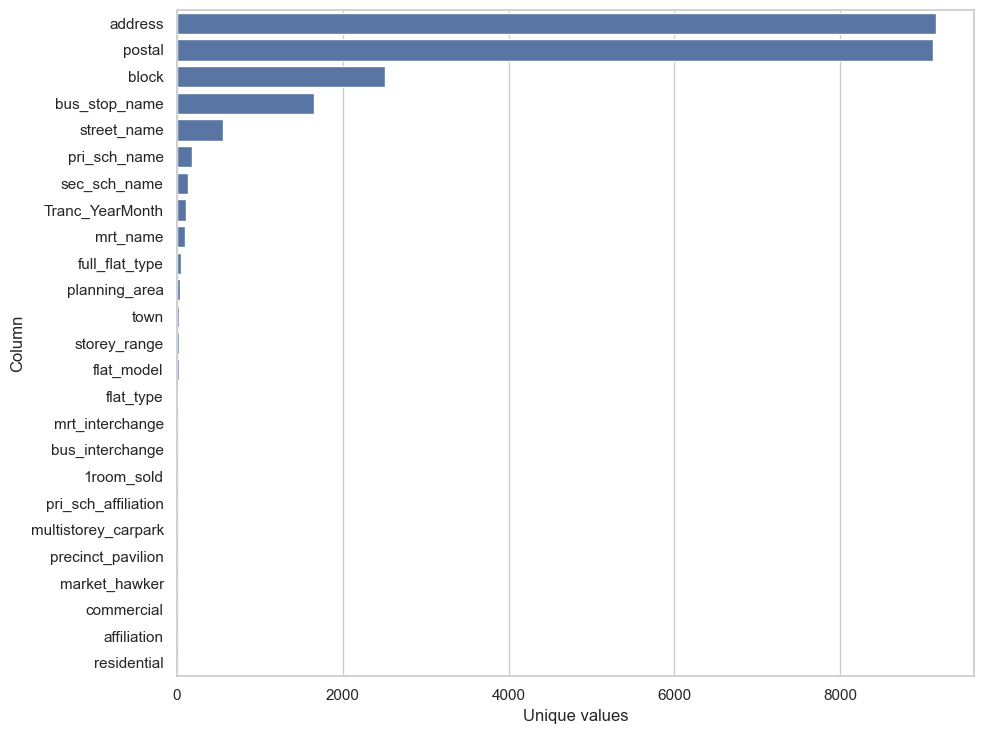

address                9157
postal                 9125
block                  2514
bus_stop_name          1657
street_name             553
pri_sch_name            177
sec_sch_name            134
Tranc_YearMonth         110
mrt_name                 94
full_flat_type           43
planning_area            32
town                     26
storey_range             25
flat_model               20
flat_type                 7
mrt_interchange           2
bus_interchange           2
1room_sold                2
pri_sch_affiliation       2
multistorey_carpark       2
precinct_pavilion         2
market_hawker             2
commercial                2
affiliation               2
residential               1
Name: unique_values, dtype: int64

In [42]:
# Verify categorical and binary columns by cardinality.
cat_binary_summary = pd.concat([
    X[categorical_cols].nunique().rename('unique_values'),
    X[binary_cols].nunique().rename('unique_values'),
]).sort_values(ascending=False)

plt.figure(figsize=(10, max(4, 0.3 * len(cat_binary_summary))))
sns.barplot(x=cat_binary_summary.values, y=cat_binary_summary.index)
plt.xlabel('Unique values')
plt.ylabel('Column')
plt.tight_layout()
plt.show()

cat_binary_summary


In [43]:
# Step 2: identify continuous numeric columns from the remaining numeric columns.
engineered_numeric_cols = ['days_from_first_transaction']
numeric_cols = [col for col in numeric_candidate_cols if col not in binary_cols] + engineered_numeric_cols

continuous_cols = [
    col for col in numeric_cols
    if 'distance' in col.lower() or 'dist' in col.lower() or col in [
        'floor_area_sqm',
        'floor_area_sqft',
        'days_from_first_transaction',
        'Latitude',
        'Longitude',
        'mrt_latitude',
        'mrt_longitude',
        'bus_stop_latitude',
        'bus_stop_longitude',
        'pri_sch_latitude',
        'pri_sch_longitude',
        'sec_sch_latitude',
        'sec_sch_longitude',
    ]
]

print(f'Continuous numeric columns ({len(continuous_cols)}):')
print(continuous_cols)

Continuous numeric columns (19):
['floor_area_sqm', 'floor_area_sqft', 'Latitude', 'Longitude', 'Mall_Nearest_Distance', 'Hawker_Nearest_Distance', 'mrt_nearest_distance', 'mrt_latitude', 'mrt_longitude', 'bus_stop_nearest_distance', 'bus_stop_latitude', 'bus_stop_longitude', 'pri_sch_nearest_distance', 'pri_sch_latitude', 'pri_sch_longitude', 'sec_sch_nearest_dist', 'sec_sch_latitude', 'sec_sch_longitude', 'days_from_first_transaction']


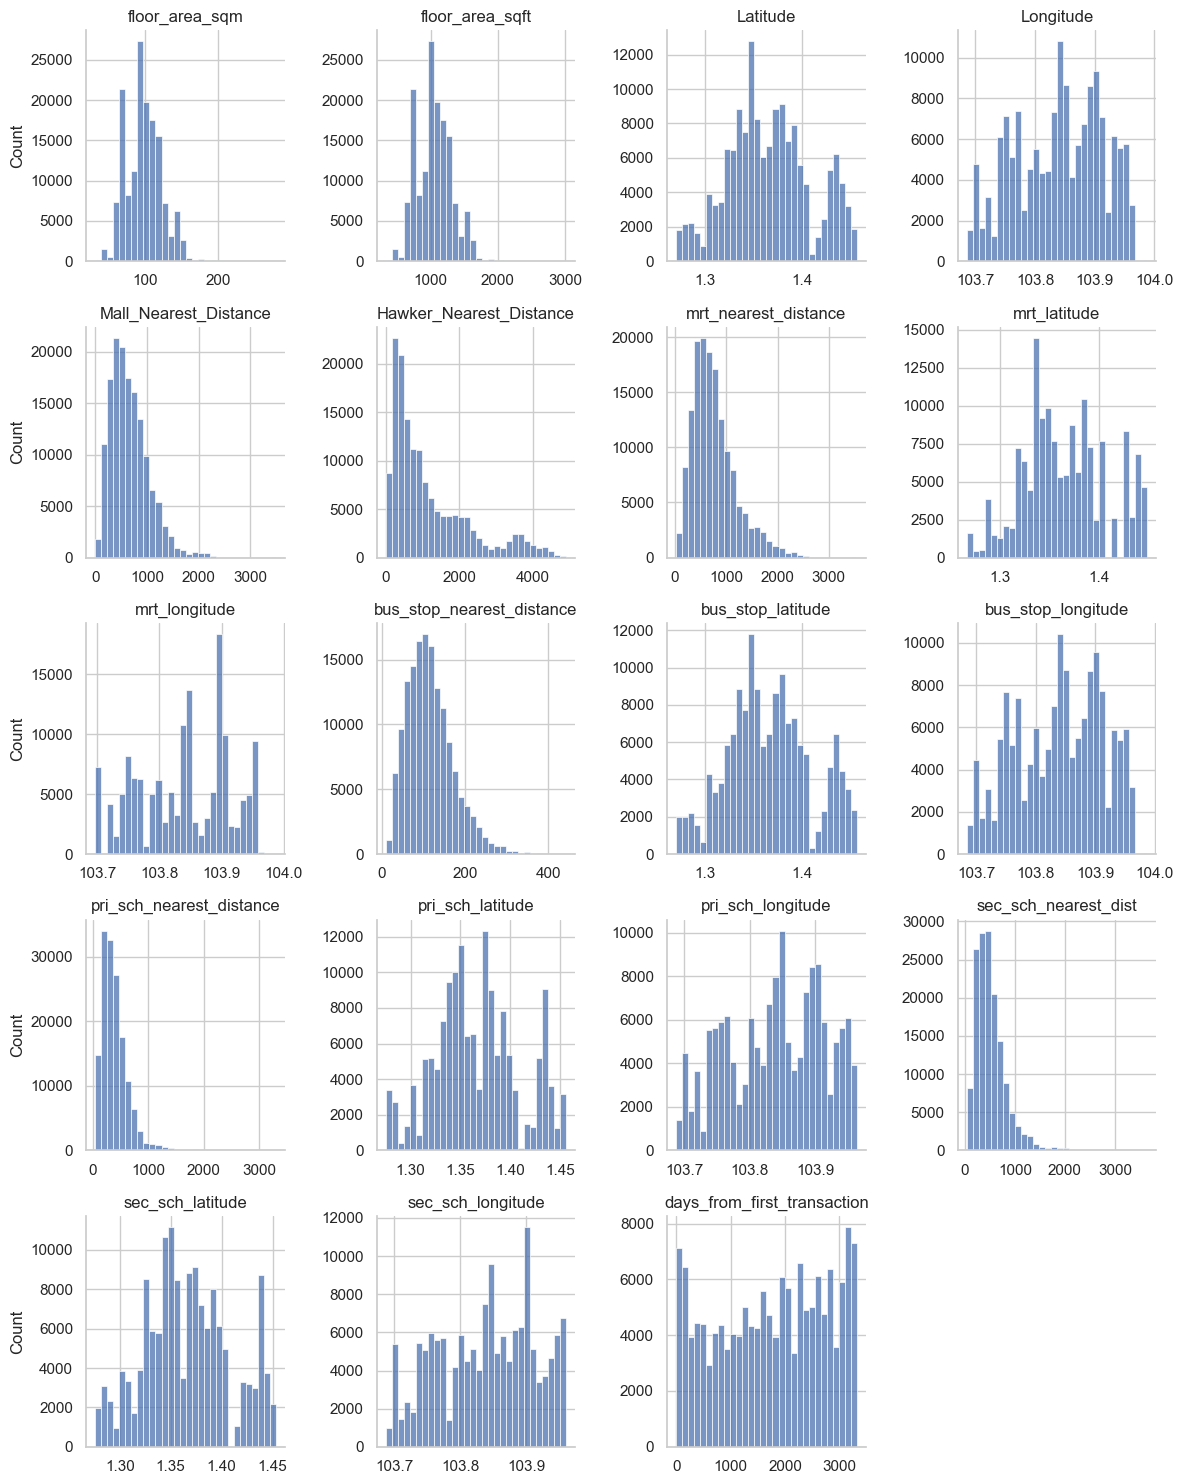

,count,mean,std,min,25%,50%,75%,max
floor_area_sqm,150634.0,97.197630,24.403040,31.000000,75.000000,95.000000,112.000000,280.000000
floor_area_sqft,150634.0,1046.235290,262.674321,333.684000,807.300000,1022.580000,1205.568000,3013.920000
Latitude,150634.0,1.366224,0.042850,1.270380,1.336285,1.363466,1.393323,1.457071
Longitude,150634.0,103.839391,0.072506,103.685228,103.774859,103.844907,103.898808,103.987804
Mall_Nearest_Distance,149805.0,664.239826,368.739209,0.000000,391.473823,602.818388,868.818288,3496.402910
Hawker_Nearest_Distance,150634.0,1173.700148,1076.701337,1.873295,372.132398,778.966980,1678.949229,4907.036414
mrt_nearest_distance,150634.0,765.007872,429.366039,21.971410,458.266301,682.621343,975.734180,3544.504228
mrt_latitude,150634.0,1.365667,0.042563,1.265982,1.336358,1.359703,1.392440,1.449057
mrt_longitude,150634.0,103.839400,0.072582,103.697143,103.773982,103.846412,103.895735,103.987305
bus_stop_nearest_distance,150634.0,115.258966,55.572855,9.001285,75.032491,107.765999,146.652409,443.964584


In [44]:
X_feature_preview = TransactionDateFeatures().fit_transform(X)

continuous_melted = X_feature_preview[continuous_cols].melt(
    var_name='variable',
    value_name='value',
)

g = sns.FacetGrid(continuous_melted, col='variable', col_wrap=4, height=3, sharey=False, sharex=False)
g.map(sns.histplot, 'value', bins=30, kde=False)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('', 'Count')
plt.tight_layout()
plt.show()

X_feature_preview[continuous_cols].describe().T

In [45]:
# Step 3: remaining non-continuous numeric columns.
other_numeric_cols = [
    col for col in numeric_cols
    if col not in continuous_cols and col not in engineered_numeric_cols
]

print(f'Remaining numeric columns ({len(other_numeric_cols)}):')
print(other_numeric_cols)

Remaining numeric columns (32):
['lease_commence_date', 'Tranc_Year', 'Tranc_Month', 'mid_storey', 'lower', 'upper', 'mid', 'hdb_age', 'max_floor_lvl', 'year_completed', 'total_dwelling_units', '2room_sold', '3room_sold', '4room_sold', '5room_sold', 'exec_sold', 'multigen_sold', 'studio_apartment_sold', '1room_rental', '2room_rental', '3room_rental', 'other_room_rental', 'Mall_Within_500m', 'Mall_Within_1km', 'Mall_Within_2km', 'Hawker_Within_500m', 'Hawker_Within_1km', 'Hawker_Within_2km', 'hawker_food_stalls', 'hawker_market_stalls', 'vacancy', 'cutoff_point']


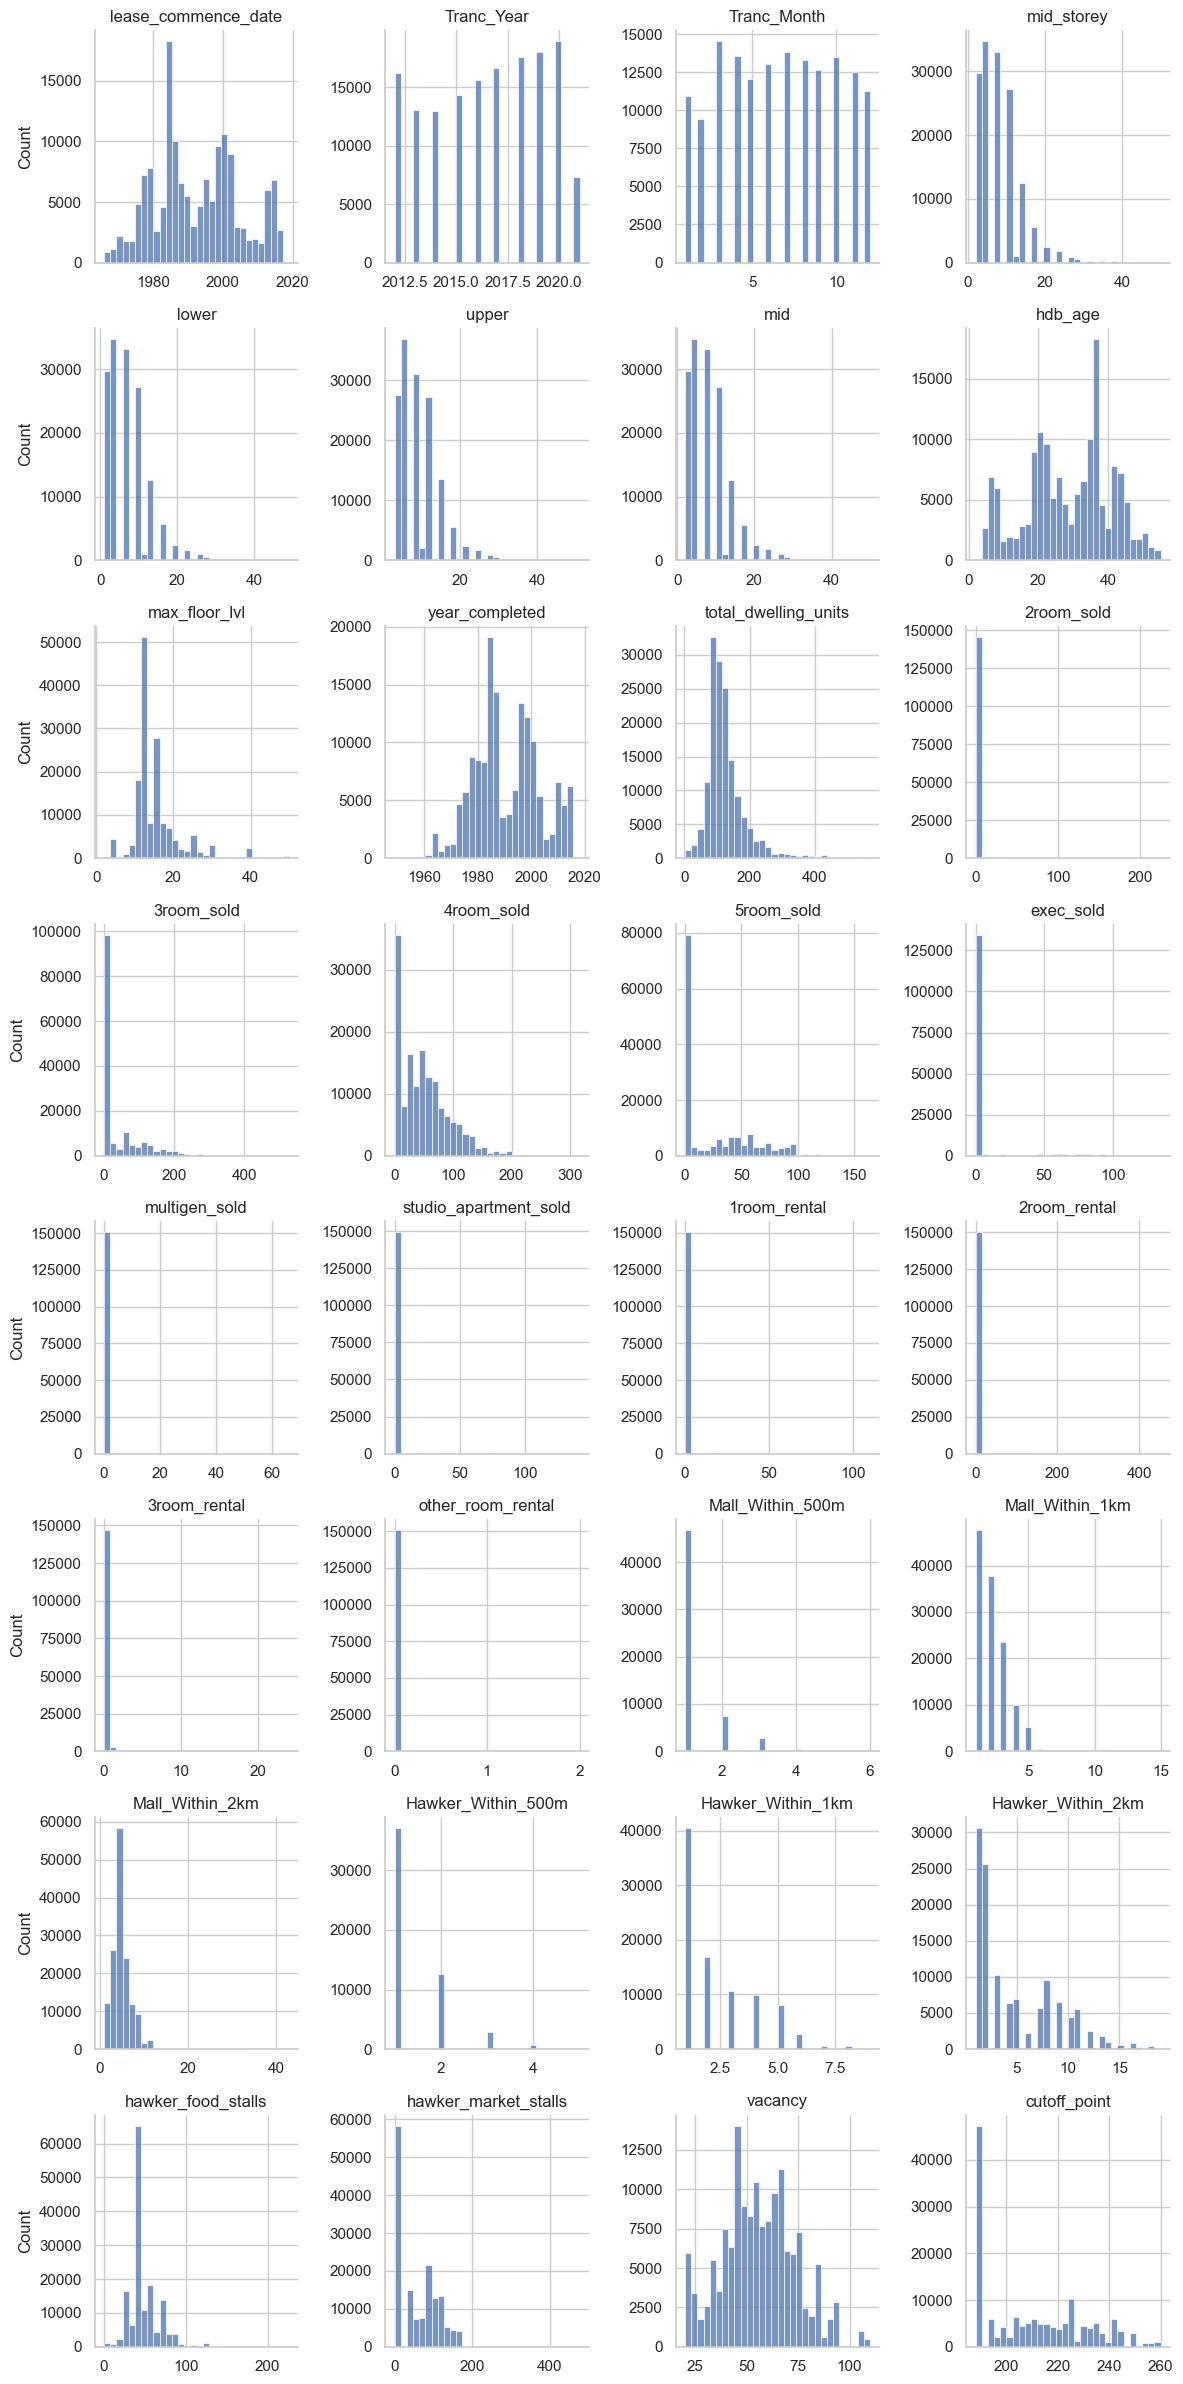

,count,mean,std,min,25%,50%,75%,max
lease_commence_date,150634.0,1992.448464,12.138829,1966.0,1984.0,1992.0,2001.0,2019.0
Tranc_Year,150634.0,2016.489551,2.752396,2012.0,2014.0,2017.0,2019.0,2021.0
Tranc_Month,150634.0,6.580500,3.345468,1.0,4.0,7.0,9.0,12.0
mid_storey,150634.0,8.284823,5.508074,2.0,5.0,8.0,11.0,50.0
lower,150634.0,7.248370,5.515155,1.0,4.0,7.0,10.0,49.0
upper,150634.0,9.321275,5.507364,3.0,6.0,9.0,12.0,51.0
mid,150634.0,8.284823,5.508074,2.0,5.0,8.0,11.0,50.0
hdb_age,150634.0,28.551536,12.138829,2.0,20.0,29.0,37.0,55.0
max_floor_lvl,150634.0,15.139816,6.232492,2.0,12.0,13.0,16.0,50.0
year_completed,150634.0,1990.922906,12.202185,1949.0,1983.0,1989.0,1999.0,2018.0


In [46]:
# Verify remaining non-continuous numeric columns.
other_numeric_melted = X[other_numeric_cols].melt(var_name='variable', value_name='value')

g = sns.FacetGrid(other_numeric_melted, col='variable', col_wrap=4, height=3, sharey=False, sharex=False)
g.map(sns.histplot, 'value', bins=30, kde=False)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('', 'Count')
plt.tight_layout()
plt.show()

X[other_numeric_cols].describe().T


## 6. Building the Preprocessing Pipeline

This is the main sklearn pipeline pattern used by the rest of the notebook. Raw feature data goes into `Pipeline`; the `feature_engineering` step creates `days_from_first_transaction`, the `preprocessor` step fills missing values with `0`, scales/encodes columns, and the final `model` step fits or predicts.

In [47]:
std_scale_cols = continuous_cols
minmax_scale_cols = binary_cols + other_numeric_cols

std_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler()),
])

minmax_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', MinMaxScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='0')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('std', std_pipeline, std_scale_cols),
    ('minmax', minmax_pipeline, minmax_scale_cols),
    ('cat', categorical_pipeline, categorical_cols),
])


def make_regression_pipeline(model):
    return Pipeline(steps=[
        ('feature_engineering', TransactionDateFeatures()),
        ('preprocessor', preprocessor),
        ('model', model),
    ])


preprocessing_summary = pd.DataFrame({
    'group': ['feature_engineering', 'imputation', 'categorical', 'binary', 'standard_scaled_continuous', 'minmax_scaled_numeric'],
    'column_count': [1, X.isna().sum().gt(0).sum(), len(categorical_cols), len(binary_cols), len(std_scale_cols), len(minmax_scale_cols)],
})

preprocessing_summary

,group,column_count
0,feature_engineering,1
1,imputation,7
2,categorical,20
3,binary,5
4,standard_scaled_continuous,19
5,minmax_scaled_numeric,37


## 7. Final Transformed Data Check

This cell fits the preprocessor to the cleaned feature matrix so the transformed columns can be inspected before modeling. The facet grid shows only the scaled numeric columns because one-hot encoding expands the categorical features into many sparse indicator columns.


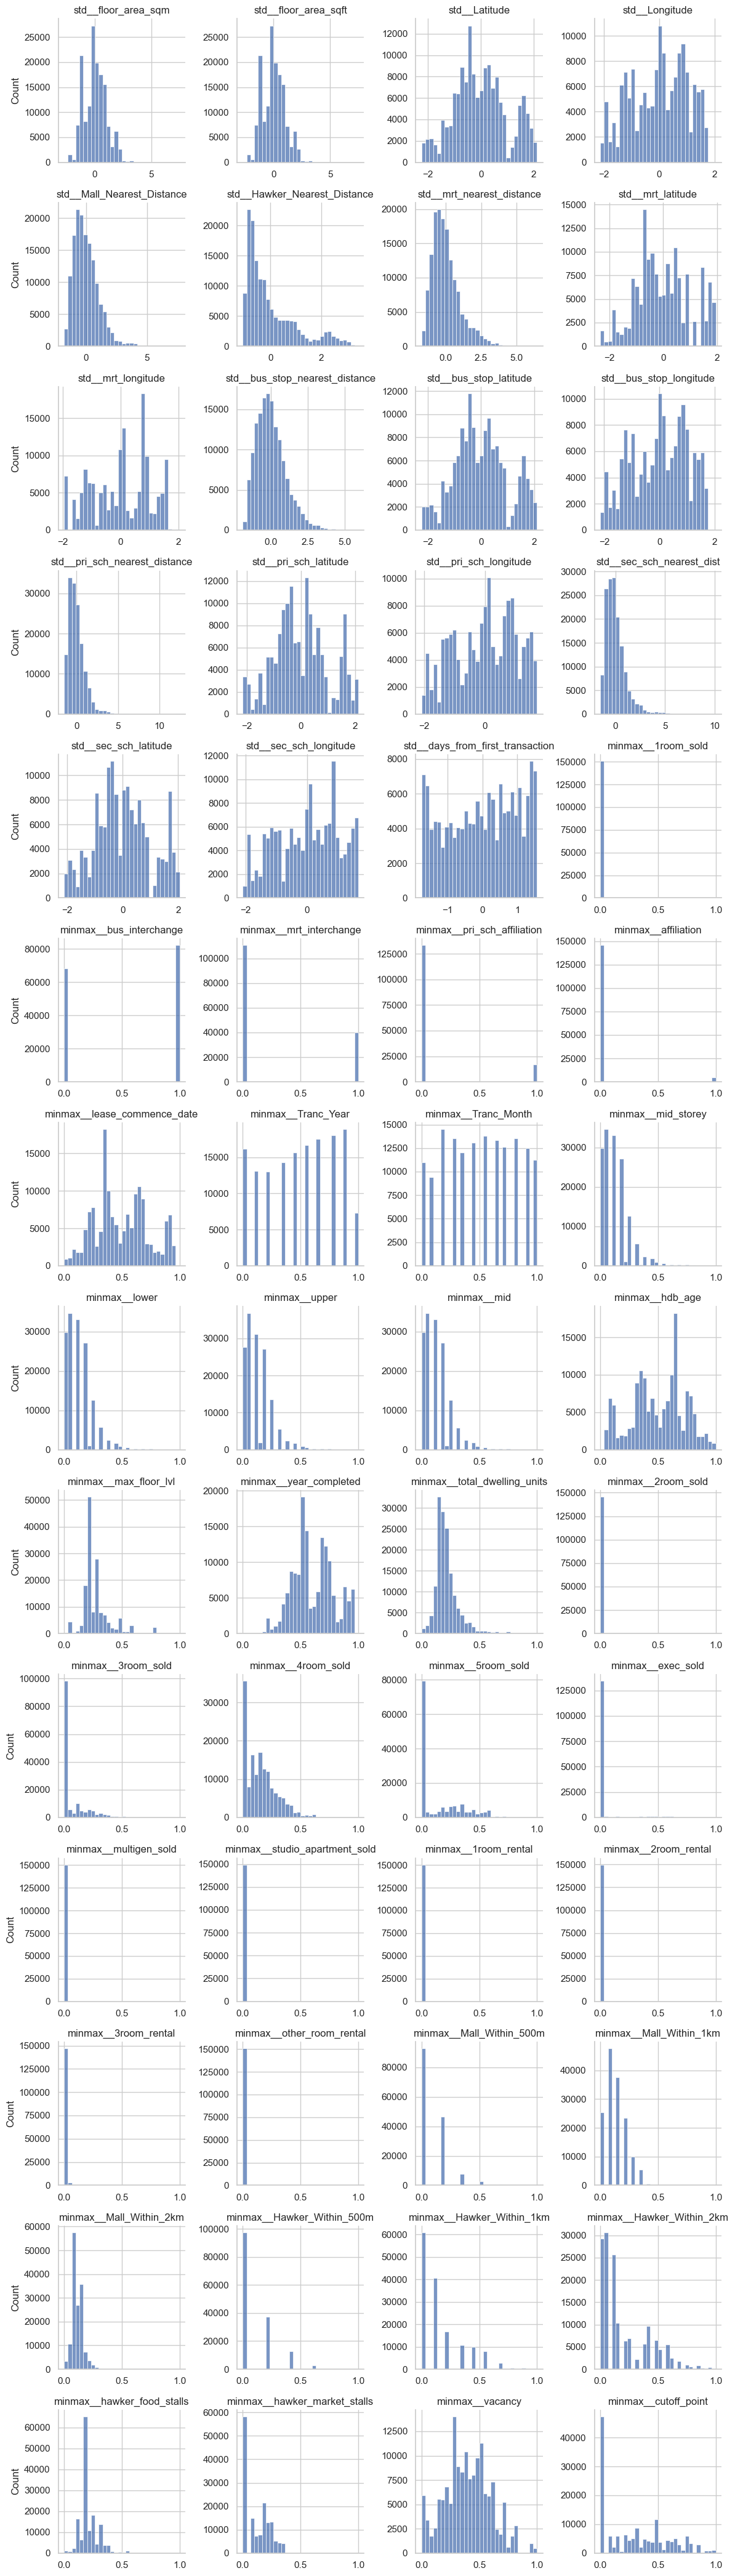

((150634, 23739),
                                      count          mean       std       min  \
 std__floor_area_sqm               150634.0 -3.018889e-17  1.000003 -2.712689   
 std__floor_area_sqft              150634.0 -1.939636e-16  1.000003 -2.712689   
 std__Latitude                     150634.0  1.010951e-15  1.000003 -2.236721   
 std__Longitude                    150634.0 -1.482407e-14  1.000003 -2.126204   
 std__Mall_Nearest_Distance        150634.0  6.037778e-18  1.000003 -1.780594   
 std__Hawker_Nearest_Distance      150634.0 -1.920768e-16  1.000003 -1.088353   
 std__mrt_nearest_distance         150634.0 -1.239631e-16  1.000003 -1.730549   
 std__mrt_latitude                 150634.0  2.590773e-15  1.000003 -2.342072   
 std__mrt_longitude                150634.0  1.767710e-13  1.000003 -1.959949   
 std__bus_stop_nearest_distance    150634.0  1.881145e-16  1.000003 -1.912049   
 std__bus_stop_latitude            150634.0  3.900027e-15  1.000003 -2.227310   
 std__bus_

In [48]:
preprocessing_pipeline = Pipeline(steps=[
    ('feature_engineering', TransactionDateFeatures()),
    ('preprocessor', preprocessor),
])

X_transformed = preprocessing_pipeline.fit_transform(X)
transformed_feature_names = preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out()

X_transformed_df = pd.DataFrame(
    X_transformed.toarray() if hasattr(X_transformed, 'toarray') else X_transformed,
    columns=transformed_feature_names,
    index=X.index,
)

scaled_feature_names = [
    col for col in transformed_feature_names
    if col.startswith('std__') or col.startswith('minmax__')
]

transformed_melted = X_transformed_df[scaled_feature_names].melt(
    var_name='variable',
    value_name='value',
)

g = sns.FacetGrid(transformed_melted, col='variable', col_wrap=4, height=3, sharey=False, sharex=False)
g.map(sns.histplot, 'value', bins=30, kde=False)
g.set_titles(col_template='{col_name}')
g.set_axis_labels('', 'Count')
plt.tight_layout()
plt.show()

X_transformed_df.shape, X_transformed_df[scaled_feature_names].describe().T

## 8. Baseline Model with 10-Fold Cross-Validation

Cross-validation uses the full cleaned training dataset to estimate how stable the baseline Linear Regression model is across different folds.


In [49]:
linear_model_pipeline = make_regression_pipeline(LinearRegression())

kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(
    linear_model_pipeline,
    X,
    Y,
    cv=kfold,
    scoring={
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error',
        'r2': 'r2',
    },
    n_jobs=-1,
)

linear_regression_cv_metrics = pd.DataFrame({
    'fold': range(1, kfold.get_n_splits() + 1),
    'MAE': -cv_results['test_mae'],
    'RMSE': -cv_results['test_rmse'],
    'R2': cv_results['test_r2'],
})

linear_regression_cv_summary = linear_regression_cv_metrics[['MAE', 'RMSE', 'R2']].agg(['mean', 'std'])
linear_regression_cv_summary


,MAE,RMSE,R2
mean,22990.723486,31340.504975,0.952165
std,117.727027,282.980681,0.000666


## 9. Train-Test Split

The train-test split is kept separate from cross-validation. The test split is used for final model comparison after models are fitted on the training split only.


In [50]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape


((120507, 75), (30127, 75), (120507,), (30127,))

## 10. Helper Function for Regression Metrics

This helper keeps the evaluation output consistent across all regression models.


In [51]:
def regression_metrics(model_name, y_train, y_train_pred, y_test, y_test_pred):
    return pd.DataFrame({
        'model': [model_name, model_name],
        'split': ['train', 'test'],
        'MAE': [
            mean_absolute_error(y_train, y_train_pred),
            mean_absolute_error(y_test, y_test_pred),
        ],
        'RMSE': [
            mean_squared_error(y_train, y_train_pred) ** 0.5,
            mean_squared_error(y_test, y_test_pred) ** 0.5,
        ],
        'R2': [
            r2_score(y_train, y_train_pred),
            r2_score(y_test, y_test_pred),
        ],
    })


## 11. Linear Regression Baseline

Fit the baseline model on the train split and evaluate it on both train and test data.


In [52]:
linear_model_pipeline = make_regression_pipeline(LinearRegression())

linear_model_pipeline.fit(X_train, Y_train)

Y_train_pred_lr = linear_model_pipeline.predict(X_train)
Y_test_pred_lr = linear_model_pipeline.predict(X_test)

linear_regression_split_metrics = regression_metrics(
    'Linear Regression',
    Y_train,
    Y_train_pred_lr,
    Y_test,
    Y_test_pred_lr,
)

linear_regression_split_metrics


,model,split,MAE,RMSE,R2
0,Linear Regression,train,21209.221173,28890.580736,0.959429
1,Linear Regression,test,23073.067605,31389.387122,0.951679


## 12. Regularized Regression Comparison

Ridge, Lasso, and Elastic Net apply regularization to reduce overfitting risk. This follows the regularization techniques from the sample notebooks, adapted for this regression problem.


In [ ]:
regularized_models = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1, max_iter=10000, random_state=42),
    'Elastic Net': ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000, random_state=42),
}

regularized_metric_frames = []
regularized_pipelines = {}

for model_name, model in regularized_models.items():
    pipeline = make_regression_pipeline(model)
    pipeline.fit(X_train, Y_train)
    regularized_pipelines[model_name] = pipeline

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    regularized_metric_frames.append(
        regression_metrics(model_name, Y_train, y_train_pred, Y_test, y_test_pred)
    )

regularized_metrics = pd.concat(
    [linear_regression_split_metrics] + regularized_metric_frames,
    ignore_index=True,
)

regularized_metrics


## 13. Elastic Net Hyperparameter Tuning

Random search tests a sampled set of `alpha` and `l1_ratio` combinations using cross-validation on the training split. The final tuned model is then evaluated once on the held-out test split.

The search is intentionally moderate so it finishes faster than a large grid.


In [ ]:
elastic_net_search_pipeline = make_regression_pipeline(
    ElasticNet(max_iter=5000, tol=1e-3, selection='random', random_state=42)
)

elastic_net_param_distributions = {
    'model__alpha': np.logspace(-2, 1, 30),
    'model__l1_ratio': np.linspace(0.1, 0.9, 9),
}

elastic_net_random_search = RandomizedSearchCV(
    estimator=elastic_net_search_pipeline,
    param_distributions=elastic_net_param_distributions,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

elastic_net_random_search.fit(X_train, Y_train)

best_elastic_net_pipeline = elastic_net_random_search.best_estimator_
Y_train_pred_en_best = best_elastic_net_pipeline.predict(X_train)
Y_test_pred_en_best = best_elastic_net_pipeline.predict(X_test)

best_elastic_net_metrics = regression_metrics(
    'Tuned Elastic Net',
    Y_train,
    Y_train_pred_en_best,
    Y_test,
    Y_test_pred_en_best,
)

elastic_net_random_search.best_params_, -elastic_net_random_search.best_score_, best_elastic_net_metrics


Fitting 3 folds for each of 10 candidates, totalling 30 fits


({'model__l1_ratio': np.float64(0.4),
  'model__alpha': np.float64(0.020433597178569417)},
 np.float64(43594.07246170311),
                model  split           MAE          RMSE        R2
 0  Tuned Elastic Net  train  31959.710209  42470.861568  0.947871
 1  Tuned Elastic Net   test  32588.143866  43096.460077  0.946595)

## 14. Model Comparison

Compare the baseline and regularized models on the held-out test split.


In [ ]:
model_comparison = pd.concat(
    [regularized_metrics, best_elastic_net_metrics],
    ignore_index=True,
)

model_comparison.sort_values(['split', 'RMSE'])


,model,split,MAE,RMSE,R2
3,Ridge,test,27267.544569,36894.420648,0.960860
1,Linear Regression,test,27370.068446,37048.453688,0.960533
5,Lasso,test,27361.218554,37055.058666,0.960519
9,Tuned Elastic Net,test,32588.143866,43096.460077,0.946595
7,Elastic Net,test,61627.164547,80822.141420,0.812173
0,Linear Regression,train,24906.140052,33738.145017,0.967104
4,Lasso,train,24910.446319,33739.132275,0.967102
2,Ridge,train,24980.317231,33806.448507,0.966971
8,Tuned Elastic Net,train,31959.710209,42470.861568,0.947871
6,Elastic Net,train,61566.811001,81165.029029,0.809615


## 15. Residual Diagnostics

Residual plots help check whether prediction errors are randomly scattered or show systematic patterns.


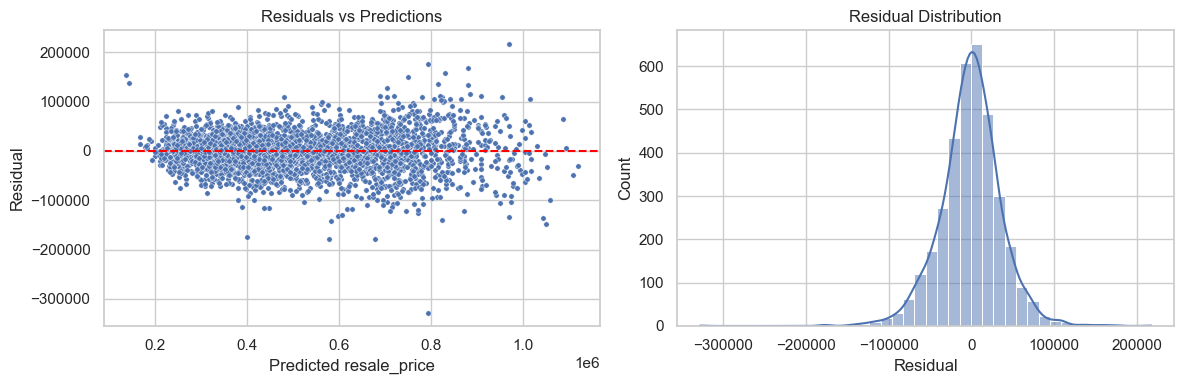

In [ ]:
residuals = Y_test - Y_test_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(x=Y_test_pred_lr, y=residuals, ax=axes[0], s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted resale_price')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predictions')

sns.histplot(residuals, bins=40, kde=True, ax=axes[1])
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()


## 16. Coefficient Inspection

For linear models, coefficients can give a rough indication of which transformed features have the largest positive or negative association with the target.


In [ ]:
linear_feature_names = linear_model_pipeline.named_steps['preprocessor'].get_feature_names_out()
linear_coefficients = linear_model_pipeline.named_steps['model'].coef_

coefficient_summary = pd.DataFrame({
    'feature': linear_feature_names,
    'coefficient': linear_coefficients,
})

coefficient_summary['abs_coefficient'] = coefficient_summary['coefficient'].abs()
coefficient_summary.sort_values('abs_coefficient', ascending=False).head(20)


,feature,coefficient,abs_coefficient
30,minmax__hdb_age,-111925.167912,111925.167912
23,minmax__lease_commence_date,111925.167911,111925.167911
1076,cat__full_flat_type_2 ROOM Model A,-108676.349154,108676.349154
31,minmax__max_floor_lvl,87674.670704,87674.670704
1096,cat__full_flat_type_5 ROOM Improved,-87479.585192,87479.585192
42,minmax__1room_rental,79887.684513,79887.684513
184,cat__flat_type_2 ROOM,-79721.245239,79721.245239
1065,cat__flat_model_Model A,-75694.151192,75694.151192
974,cat__street_name_MOH GUAN TER,71075.293909,71075.293909
1100,cat__full_flat_type_5 ROOM Standard,67636.100630,67636.100630
